# ネットワーク力学の基礎：3頂点の線形モデル

対応章: [`../chapters/42_love_dynamics_network.md`](../chapters/42_love_dynamics_network.md)

意味を限定しない3頂点モデルで隣接行列と結合ODEを練習する．感情行列，第三者効果，物語アノテーション，係数推定は卒業研究として残す．

## 1. ライブラリと隣接行列

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import solve_ivp

labels = ['node 1', 'node 2', 'node 3']
# A[i, j] means influence from node j to node i.
A = np.array([
    [0.0, 0.8, 0.0],
    [0.0, 0.0, 1.0],
    [0.5, 0.0, 0.0],
])
A

array([[0. , 0.8, 0. ],
       [0. , 0. , 1. ],
       [0.5, 0. , 0. ]])

## 2. 行列と有向グラフを照合する

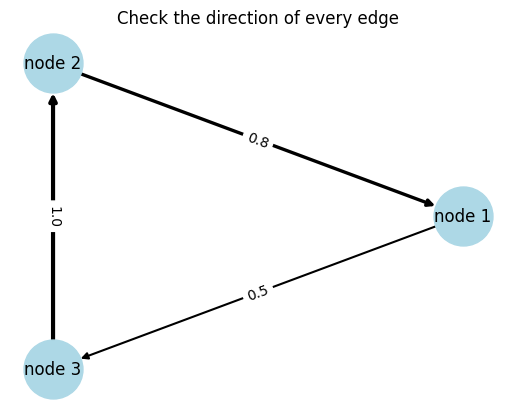

In [2]:
G = nx.DiGraph()
G.add_nodes_from(range(3))
for i in range(3):
    for j in range(3):
        if A[i, j] != 0:
            G.add_edge(j, i, weight=A[i, j])
pos = nx.circular_layout(G)
widths = [3 * G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx(G, pos, labels={i: labels[i] for i in range(3)}, node_color='lightblue',
                 node_size=1800, arrows=True, width=widths)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{G[u][v]['weight']:.1f}" for u, v in G.edges()})
plt.title('Check the direction of every edge')
plt.axis('off'); plt.show()

## 3. 結合ODEと固有値

In [3]:
alpha = 0.8
beta = 0.6
M = -alpha * np.eye(3) + beta * A
eigenvalues = np.linalg.eigvals(M)
print('M =\n', M)
print('eigenvalues =', eigenvalues)
print('largest real part =', eigenvalues.real.max())

M =
 [[-0.8   0.48  0.  ]
 [ 0.   -0.8   0.6 ]
 [ 0.3   0.   -0.8 ]]
eigenvalues = [-1.02104189+0.38285578j -1.02104189-0.38285578j -0.35791622+0.j        ]
largest real part = -0.35791622016315366


## 4. 1頂点から影響が伝わる時系列

初期状態はnode 1だけを非ゼロにする．どの順に他頂点へ伝わるかをグラフから予想してから実行する．

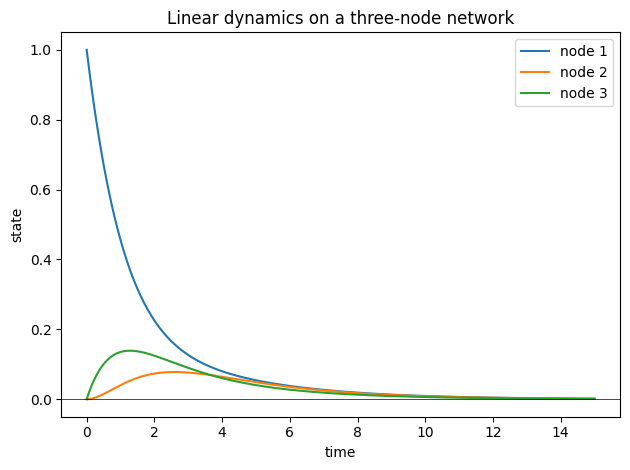

In [4]:
def rhs(t, x, M):
    return M @ x

t_eval = np.linspace(0, 15, 400)
x0 = np.array([1.0, 0.0, 0.0])
solution = solve_ivp(rhs, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval, args=(M,))
for i, label in enumerate(labels):
    plt.plot(solution.t, solution.y[i], label=label)
plt.axhline(0, color='black', lw=0.5)
plt.xlabel('time'); plt.ylabel('state')
plt.title('Linear dynamics on a three-node network')
plt.legend(); plt.tight_layout(); plt.show()

## 5. 結合強度と最大固有値実部

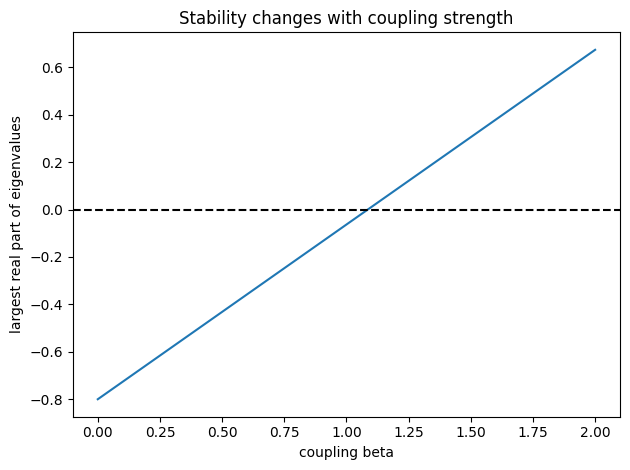

In [5]:
betas = np.linspace(0.0, 2.0, 200)
max_real_parts = [np.linalg.eigvals(-alpha*np.eye(3) + b*A).real.max() for b in betas]
plt.plot(betas, max_real_parts)
plt.axhline(0, color='black', ls='--')
plt.xlabel('coupling beta'); plt.ylabel('largest real part of eigenvalues')
plt.title('Stability changes with coupling strength')
plt.tight_layout(); plt.show()

## 6. 課題

1. 一方向の鎖 `node 1 -> node 2 -> node 3` を表す `A` を作る．
2. 非対称な `A` で，行列とnetworkxの矢印が一致するか全辺を確認する．
3. `alpha` と `beta` を変え，固有値の予想と時系列を比較する．
4. 研究用Notebookは別に作る．感情変数，第三者効果，物語イベント，推定法は対象作品と研究質問を決めてから学生自身が導入する．